<a href="https://colab.research.google.com/github/shaikhdaiyaan251-cloud/CODE-ALPHA-DATA-SCIENCE-INTERNSHIP-TASK-1/blob/main/DATA_SCIENCE_INTERNSHIP_TASK_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TASK 1 : IRIS FLOWER CLASSIFICATION**#

## **1.1. Importing the necessary Python Libraries**

## **1.2. Loading and Exploring the Dataset (Iris Dataset)**

 1.2.1 Loading the dataset

 1.2.2 Basic Exploration

 1.2.3 Visual Exploration (EDA)

## **1.3. Visualizing the Data**

 1.3.1 3D Scatter Plot (Plotly)

 1.3.2 Violin Plots + Swarm Overlay

 1.3.3 PCA Projection (2D) with Confidence Ellipses

 1.3.4 Correlation Matrix with Mask & Dendrogram (Clustered Heatmap)


## **1.4. Preprocessing the Data**
1.4.1 Separating Features (X) and Target (y)

 1.4.2 Split into Training and Testing Sets (80% training, 20% testing)

 1.4.3 Feature Scaling (Standardization)

 1.4.4 Check for Class Imbalance

 1.4.5 Save preprocessed data (for later use)

## **1.5. Training a Classification Model**
1.5.1 Defining Models to Train

 1.5.2 Training Each Model and Record Performance

 1.5.3 Displaying Results Summary

 1.5.4 Visual Comparison of Model Accuracies

 1.5.5 Detailed Evaluation of the Model

 1.5.6 Saving the Model

## **1.6. Evaluating the Model – Comprehensive Analysis**
 1.6.1 Cross-Validation (k-fold)

 1.6.2 Detailed Metrics on Test Set

 1.6.3 Confusion Matrix (with percentages)

 1.6.4 ROC Curves

 1.6.5 Learning Curves (Check for Overfitting/Underfitting)

 1.6.6 Feature Importance (for tree-based models)

 1.6.7 Summarizing Evaluation Report

## **1.7. Improve / Experiment – Going Beyond Baseline**
  1.7.1 Hyperparameter Tuning (Grid Search)

 1.7.2 Ensemble Methods: Voting Classifier

 1.7.3 Stacking Classifier (Meta-Learner)

 1.7.4 Dimensionality Reduction + Model (PCA + Classifier)

 1.7.5 Simple Neural Network (using MLPClassifier)

 1.7.6 Experiment: Adding Noise to Test Robustness

 1.7.7 Comparison of All Improved Models

 1.7.8 Saving the Best Overall Model

## **1.8. Saving & Documenting Results**
1.8.1 Create a Results Directory

 1.8.2 Save the Best Model

 1.8.3 Save Predictions on Test Set

 1.8.4 Save Evaluation Metrics to JSON

 1.8.5 Generate a Summary Report (Text)

 1.8.6 Saving All Visualizations as High-Resolution Images

 1.8.6.1 Confusion Matrix (Counts)

 1.8.6.2 Feature Importance

 1.8.6.3 Training History / Learning Curves

 1.8.7 Generating a README.md for GitHub



## **1.1. Importing the necessary Python Libraries**


In [ ]:
from google.colab import files
# 1. Importing the necessary Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


##**1.2. Loading and Exploring the Dataset (Iris Dataset)**

 1.2.1 Loading the dataset

 1.2.2 Basic Exploration

 1.2.3 Visual Exploration (EDA)


First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 n

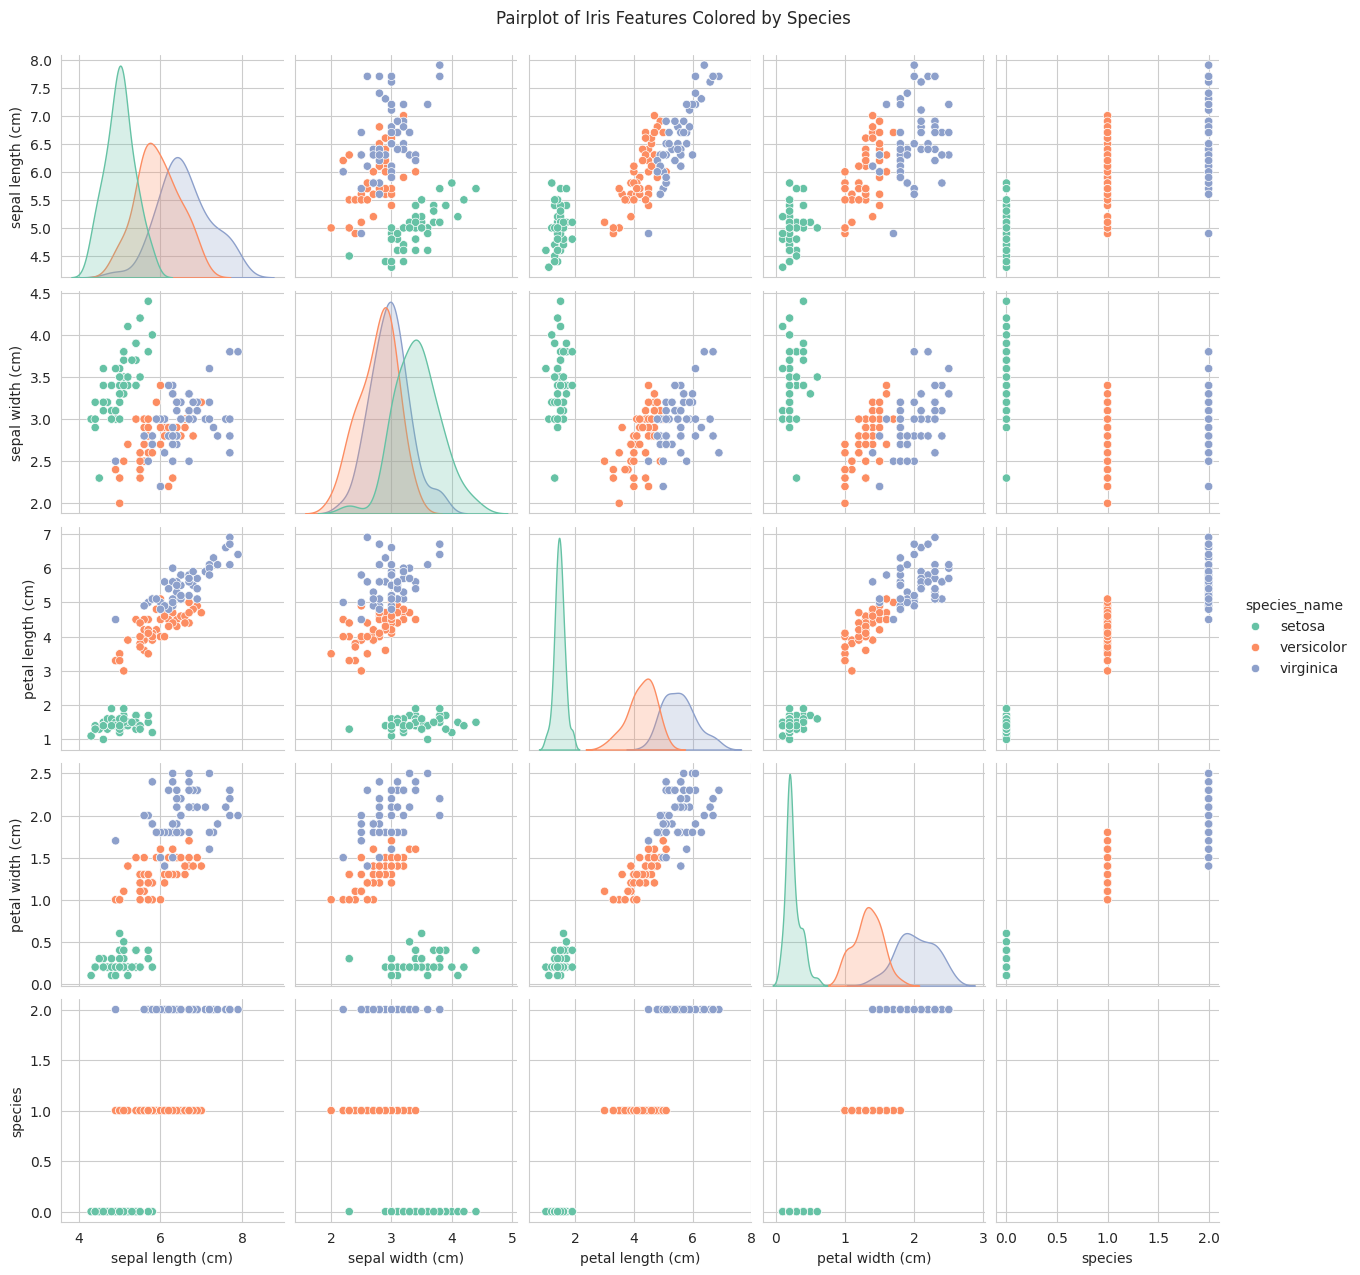

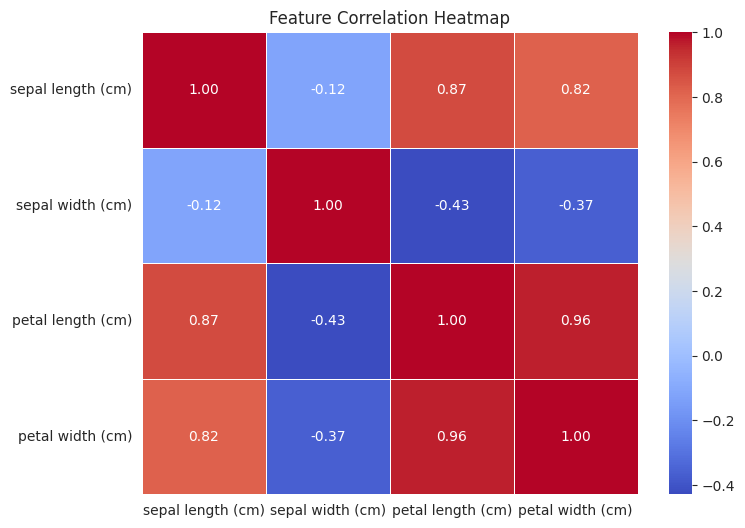

/tmp/ipykernel_3365/3318788216.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=features[i], data=df, ax=ax, palette='Set2')
/tmp/ipykernel_3365/3318788216.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=features[i], data=df, ax=ax, palette='Set2')
/tmp/ipykernel_3365/3318788216.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=features[i], data=df, ax=ax, palette='Set2')
/tmp/ipykernel_3365/3318788216.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is 

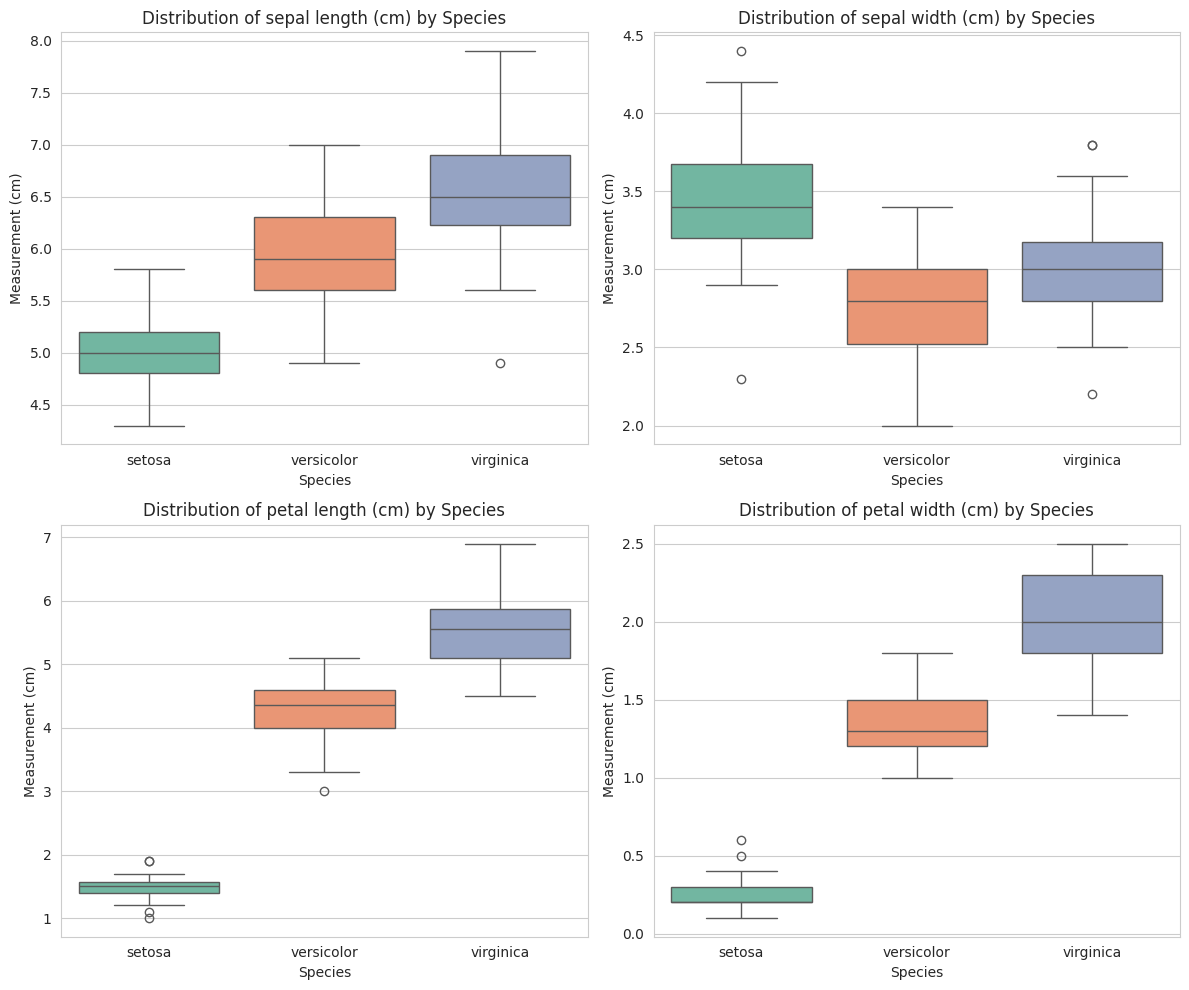

In [ ]:
# 1.2. Loading and Exploring the Dataset (Iris Dataset)


# 1.2.1 Loading the dataset
iris = load_iris()

# Converting to pandas DataFrame for easier manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Adding the targeted (species) column
df['species'] = iris.target

# Maping numeric target to actual species names for better readability
species_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_mapping)

# 1.2.2 Basic Exploration
print("="*50)
print("First 5 rows of the dataset:")
print(df.head())

print("\n" + "="*50)
print("Dataset Info:")
print(df.info())

print("\n" + "="*50)
print("Summary statistics:")
print(df.describe())

print("\n" + "="*50)
print("Check for missing values:")
print(df.isnull().sum())

print("\n" + "="*50)
print("Class distribution (how many flowers per species):")
print(df['species_name'].value_counts())

# 1.2.3 Visual Exploration (EDA)
# Seting a professional style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Pairplot - shows relationships between all feature pairs, colored by species
sns.pairplot(df, hue='species_name', diag_kind='kde', palette='Set2')
plt.suptitle('Pairplot of Iris Features Colored by Species', y=1.02)
plt.show()

# 2. Correlation heatmap (only numeric features)
plt.figure(figsize=(8, 6))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Boxplots - distribution of each feature per species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = iris.feature_names
for i, ax in enumerate(axes.flat):
    sns.boxplot(x='species_name', y=features[i], data=df, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {features[i]} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel('Measurement (cm)')
plt.tight_layout()
plt.show()

## **1.3. Visualizing the Data**

 1.3.1 3D Scatter Plot (Plotly)

 1.3.2 Violin Plots + Swarm Overlay

 1.3.3 PCA Projection (2D) with Confidence Ellipses

 1.3.4 Correlation Matrix with Mask & Dendrogram (Clustered Heatmap)


/tmp/ipykernel_3365/3516353858.py:46: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.


/tmp/ipykernel_3365/3516353858.py:46: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.


/tmp/ipykernel_3365/3516353858.py:46: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.


/tmp/ipykernel_3365/3516353858.py:46: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.




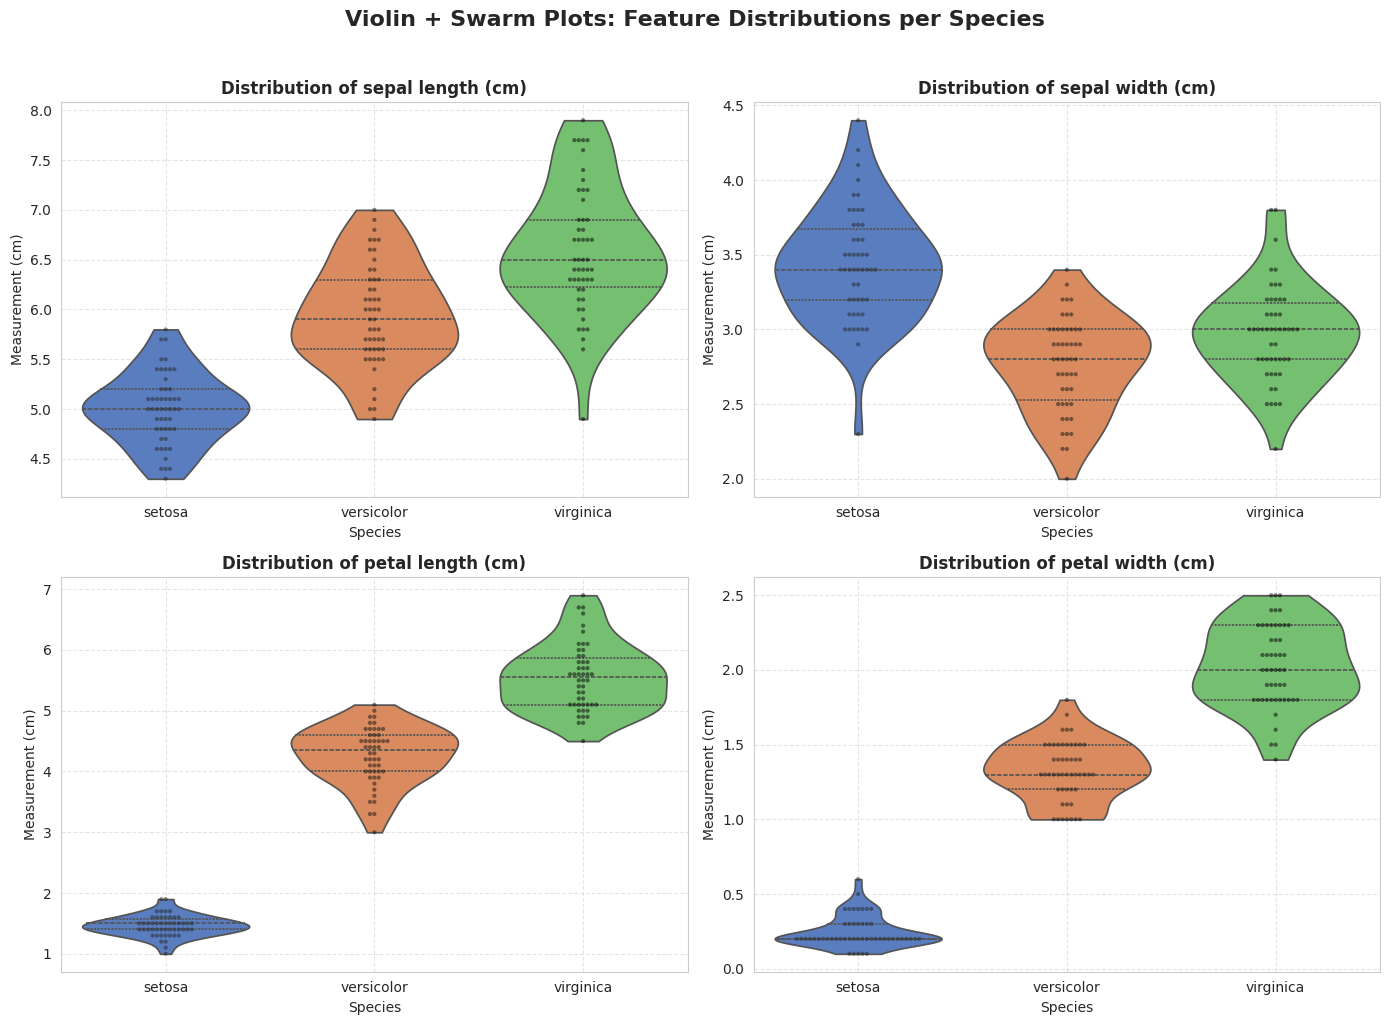

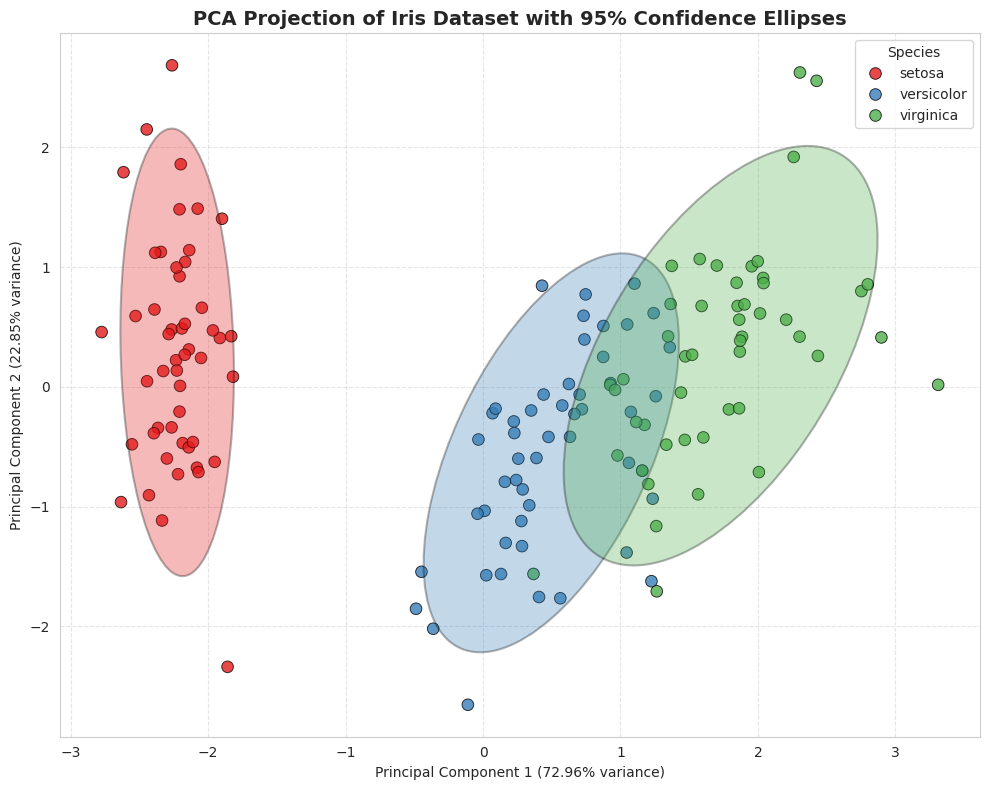

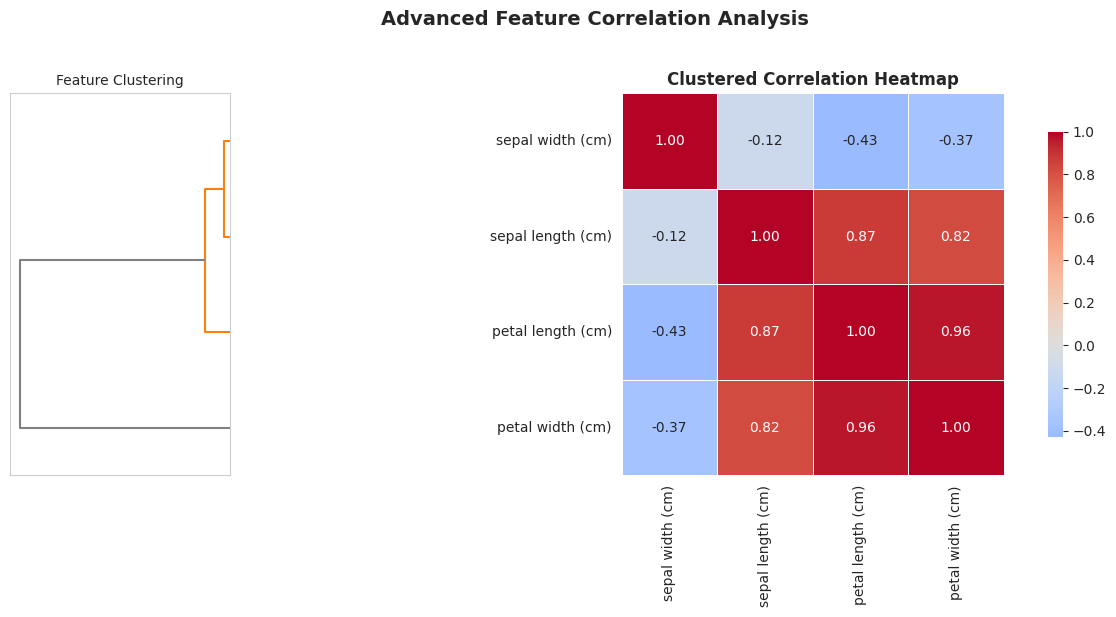

In [ ]:
# 1.3. Visualizing the Data
from sklearn.datasets import load_iris
import plotly.express as px # Import plotly.express
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
species_map = {0:'setosa',1:'versicolor',2:'virginica'}
df['species_name'] = df['species'].map(species_map)

# 1.3.1 3D Scatter Plot (Plotly)
fig_3d = px.scatter_3d(
    df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    z='petal length (cm)',
    color='species_name',
    symbol='species_name',
    size='petal width (cm)',
    size_max=12,
    opacity=0.8,
    title='<b>3D Visualization of Iris Species</b><br>Sepal Length vs Sepal Width vs Petal Length',
    labels={'sepal length (cm)': 'Sepal Length (cm)',
            'sepal width (cm)': 'Sepal Width (cm)',
            'petal length (cm)': 'Petal Length (cm)'},
    color_discrete_map={'setosa':'#1f77b4', 'versicolor':'#ff7f0e', 'virginica':'#2ca02c'}
)
fig_3d.update_traces(marker=dict(line=dict(width=0.5, color='DarkSlateGrey')))
fig_3d.update_layout(scene=dict(
    xaxis_title='Sepal Length (cm)',
    yaxis_title='Sepal Width (cm)',
    zaxis_title='Petal Length (cm)'),
    width=900, height=700,
    title_font_size=16
)
fig_3d.show()


# 1.3.2 Violin Plots + Swarm Overlay
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = iris.feature_names
for i, ax in enumerate(axes.flat):
    # Violin plot (shows full distribution)
    sns.violinplot(x='species_name', y=features[i], data=df,
                   inner='quartile', palette='muted', hue='species_name', legend=False, ax=ax, cut=0)
    # Overlay with swarmplot (shows individual points)
    sns.swarmplot(x='species_name', y=features[i], data=df,
                  color='black', alpha=0.5, size=3, hue='species_name', legend=False, ax=ax)
    ax.set_title(f'Distribution of {features[i]}', fontsize=12, weight='bold')
    ax.set_xlabel('Species', fontsize=10)
    ax.set_ylabel('Measurement (cm)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Violin + Swarm Plots: Feature Distributions per Species',
             fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 1.3.3 PCA Projection (2D) with Confidence Ellipses
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA # Add this import as PCA is used here

# Standardizing features before PCA
features_only = df[iris.feature_names]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_only)

# Applying PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_pca['species_name'] = df['species_name']

# Calculating explained variance ratio
expl_var = pca.explained_variance_ratio_

# Plotting with ellipses (95% confidence)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='species_name',
                palette='Set1', s=70, edgecolor='black', alpha=0.8)
# Adding ellipses for each species
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    """Draw a confidence ellipse around a set of points"""
    cov = np.cov(x, y)
    pearson = cov[0,1]/np.sqrt(cov[0,0]*cov[1,1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x*2, height=ell_radius_y*2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0,0]) * n_std
    scale_y = np.sqrt(cov[1,1]) * n_std
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(np.mean(x), np.mean(y))
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

for species in df_pca['species_name'].unique():
    subset = df_pca[df_pca['species_name'] == species]
    confidence_ellipse(subset['PC1'], subset['PC2'], plt.gca(),
                       n_std=2, edgecolor='black', linewidth=1.5, alpha=0.3,
                       facecolor=plt.cm.Set1.colors[list(df_pca['species_name'].unique()).index(species)])

plt.xlabel(f'Principal Component 1 ({expl_var[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({expl_var[1]*100:.2f}% variance)')
plt.title('PCA Projection of Iris Dataset with 95% Confidence Ellipses', fontsize=14, weight='bold')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 1.3.4 Correlation Matrix with Mask & Dendrogram (Clustered Heatmap)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt # Ensure plt is imported for this section
import seaborn as sns # Ensure sns is imported for this section

# Computing correlation matrix
corr = df[iris.feature_names].corr()

# Generating linkage for dendrogram
linkage_result = linkage(squareform(1 - corr), method='average')

# Plot clustered heatmap
fig, (ax_dendro, ax_heat) = plt.subplots(1, 2, figsize=(12, 6),
                                         gridspec_kw={'width_ratios': [1, 4]})

# Dendrogram
with plt.rc_context({'lines.linewidth': 1.5}):
    dendro = dendrogram(linkage_result, ax=ax_dendro, labels=corr.columns, orientation='left',
               color_threshold=0.5, above_threshold_color='gray')
ax_dendro.set_title('Feature Clustering', fontsize=10)
ax_dendro.set_xticks([])
ax_dendro.set_yticks([])

# Heatmap with clustering order
order = dendro['leaves'] # Get the order of leaves from the dendrogram
corr_clustered = corr.iloc[order, order]
sns.heatmap(corr_clustered, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax_heat,
            cbar_kws={'shrink': 0.8})
ax_heat.set_title('Clustered Correlation Heatmap', fontsize=12, weight='bold')
plt.suptitle('Advanced Feature Correlation Analysis', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

##**1.4. Preprocessing the Data**
 1.4.1 Separating Features (X) and Target (y)

 1.4.2 Split into Training and Testing Sets (80% training, 20% testing)

 1.4.3 Feature Scaling (Standardization)

 1.4.4 Check for Class Imbalance

 1.4.5 Save preprocessed data (for later use)


In [ ]:
# 1.4. Preprocessing the Data
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target


# 1.4.1 Separating Features (X) and Target (y)
X = df[iris.feature_names]   # Feature matrix (150 rows, 4 columns)
y = df['species']             # Target vector (150 values: 0,1,2)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature names:", list(X.columns))
print("Unique target values:", y.unique())


# 1.4.2 Split into Training and Testing Sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")


# 1.4.3 Feature Scaling (Standardization)

# Tree-based models (Random Forest)
scaler = StandardScaler()

# Fit scaler on training data only (to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Transforming test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Converting back to DataFrame for easier viewing (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=iris.feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=iris.feature_names)

print("\nBefore scaling - Training set mean (approx):")
print(X_train.mean().round(2))
print("\nAfter scaling - Training set mean (approx):")
print(X_train_scaled_df.mean().round(2))

print("\nBefore scaling - Training set std (approx):")
print(X_train.std().round(2))
print("\nAfter scaling - Training set std (approx):")
print(X_train_scaled_df.std().round(2))

# 1.4.4 Check for Class Imbalance
print("\nClass distribution in full dataset:")
print(y.value_counts())
print("\nThe dataset is perfectly balanced (50 samples per class). No resampling needed.")

# 1.4.5 Save preprocessed data (for later use)
X_train_scaled_df.to_csv('X_train_scaled.csv', index=False)
X_test_scaled_df.to_csv('X_test_scaled.csv', index=False)
pd.DataFrame(y_train).to_csv('y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('y_test.csv', index=False)

print("\n✅ Preprocessing complete. Data ready for model training.")

Features shape: (150, 4)
Target shape: (150,)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Unique target values: [0 1 2]

Training set size: 120 samples
Test set size: 30 samples

Training class distribution:
species
0    40
2    40
1    40
Name: count, dtype: int64

Test class distribution:
species
0    10
2    10
1    10
Name: count, dtype: int64

Before scaling - Training set mean (approx):
sepal length (cm)    5.84
sepal width (cm)     3.05
petal length (cm)    3.77
petal width (cm)     1.20
dtype: float64

After scaling - Training set mean (approx):
sepal length (cm)   -0.0
sepal width (cm)    -0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

Before scaling - Training set std (approx):
sepal length (cm)    0.84
sepal width (cm)     0.45
petal length (cm)    1.77
petal width (cm)     0.76
dtype: float64

After scaling - Training set std (approx):
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length

##**1.5. Training a Classification Model**
 1.5.1 Defining Models to Train

 1.5.2 Training Each Model and Record Performance

 1.5.3 Displaying Results Summary

 1.5.4 Visual Comparison of Model Accuracies

 1.5.5 Detailed Evaluation of the Model

 1.5.6 Saving the Model



Training and Evaluating Multiple Classifiers

✅ Logistic Regression
   Accuracy: 0.9333 (93.33%)
   Time: 0.0200 seconds

✅ K-Nearest Neighbors (k=3)
   Accuracy: 0.9333 (93.33%)
   Time: 0.0060 seconds

✅ K-Nearest Neighbors (k=5)
   Accuracy: 0.9333 (93.33%)
   Time: 0.0043 seconds

✅ Support Vector Machine (RBF)
   Accuracy: 0.9667 (96.67%)
   Time: 0.0041 seconds

✅ Decision Tree
   Accuracy: 0.9333 (93.33%)
   Time: 0.0032 seconds

✅ Random Forest (100 trees)
   Accuracy: 0.9000 (90.00%)
   Time: 0.2040 seconds

✅ Gradient Boosting
   Accuracy: 0.9667 (96.67%)
   Time: 0.3613 seconds

📊 Model Performance Summary (Sorted by Accuracy)
                       Model  Accuracy  Training Time (s)
Support Vector Machine (RBF)  0.966667             0.0041
           Gradient Boosting  0.966667             0.3613
         Logistic Regression  0.933333             0.0200
   K-Nearest Neighbors (k=5)  0.933333             0.0043
   K-Nearest Neighbors (k=3)  0.933333             0.0060
      

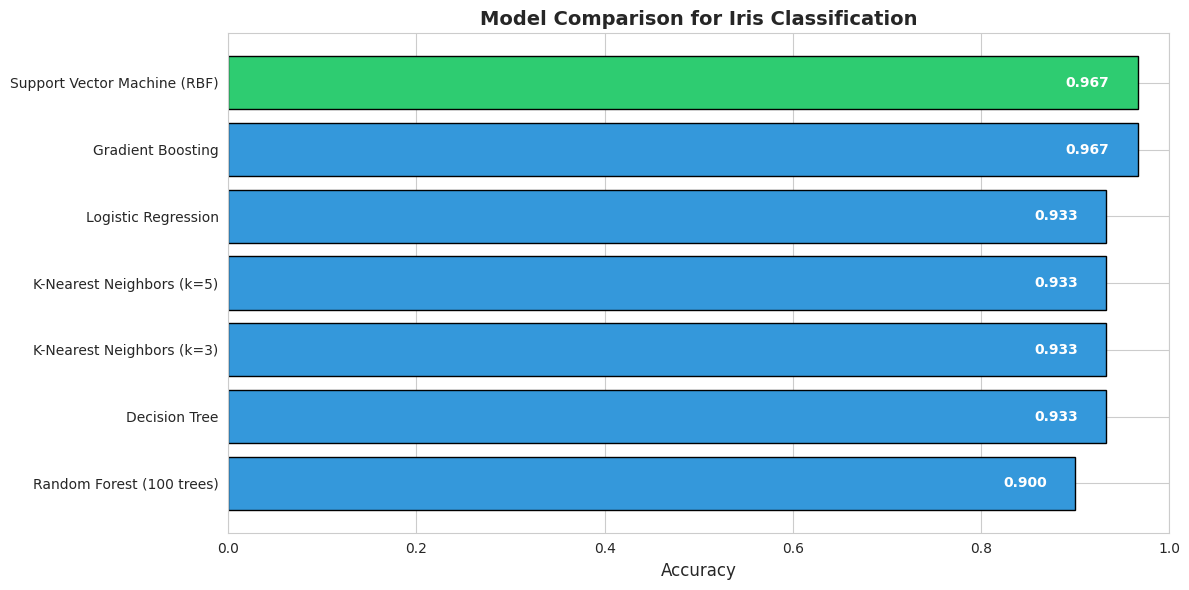


   Best Model: Support Vector Machine (RBF)
   Test Accuracy: 0.9667 (96.67%)

📋 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



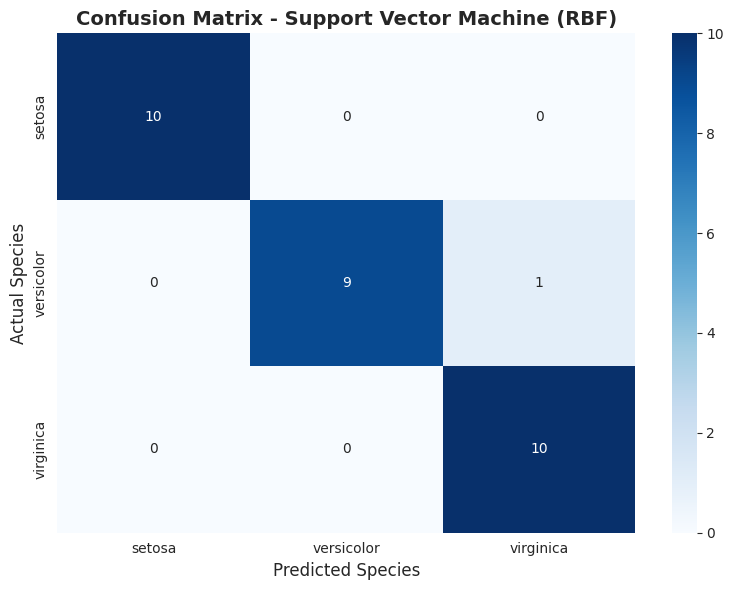


💾 Model saved as 'best_iris_classifier.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1.5. Training a Classification Model


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Assuming X_train_scaled, X_test_scaled, y_train, y_test are already defined
# from the preprocessing step. If not, run that cell first.

# 5.1 Defining Models to Train
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors (k=3)': KNeighborsClassifier(n_neighbors=3),
    'K-Nearest Neighbors (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine (RBF)': SVC(kernel='rbf', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest (100 trees)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# 1.5.2 Training Each Model and Record Performance
results = []
best_model = None
best_accuracy = 0

print("="*60)
print("Training and Evaluating Multiple Classifiers")
print("="*60)

for name, model in models.items():
    start_time = time.time()

    # Training the model
    model.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = model.predict(X_test_scaled)

    # Calculating accuracy
    acc = accuracy_score(y_test, y_pred)

    # Training time
    elapsed = time.time() - start_time

    # Storing results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Training Time (s)': round(elapsed, 4)
    })

    # Tracking best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

    print(f"\n✅ {name}")
    print(f"   Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"   Time: {elapsed:.4f} seconds")

# 1.5.3 Displaying Results Summary
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)
print("\n" + "="*60)
print("📊 Model Performance Summary (Sorted by Accuracy)")
print("="*60)
print(results_df.to_string(index=False))

# 1.5.4 Visual Comparison of Model Accuracies
plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = plt.barh(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black')
plt.xlabel('Accuracy', fontsize=12)
plt.title('Model Comparison for Iris Classification', fontsize=14, weight='bold')
plt.xlim(0, 1.0)
plt.gca().invert_yaxis()

# Adding accuracy labels on bars
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_width() - 0.03, bar.get_y() + bar.get_height()/2,
             f'{acc:.3f}', ha='right', va='center', fontsize=10, color='white', weight='bold')

plt.tight_layout()
plt.show()


# 1.5.5 Detailed Evaluation of the Model
print("\n" + "="*60)
print(f"   Best Model: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print("="*60)

# Predicting with the model
y_pred_best = best_model.predict(X_test_scaled)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=['setosa', 'versicolor', 'virginica']))

# Confusion Matrix (visualized)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, weight='bold')
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('Actual Species', fontsize=12)
plt.tight_layout()
plt.show()


# 1.5.6 Saving the Model
import joblib

# Saving model to file
joblib.dump(best_model, 'best_iris_classifier.pkl')
print(f"\n💾 Model saved as 'best_iris_classifier.pkl'")

# For Colab
from google.colab import files
files.download('best_iris_classifier.pkl')

##**1.6. Evaluating the Model – Comprehensive Analysis**
 1.6.1 Cross-Validation (k-fold)

 1.6.2 Detailed Metrics on Test Set

 1.6.3 Confusion Matrix (with percentages)

 1.6.4 ROC Curves

 1.6.5 Learning Curves (Check for Overfitting/Underfitting)

 1.6.6 Feature Importance (for tree-based models)

 1.6.7 Summarizing Evaluation Report


🔍 6.1 Cross-Validation (5-fold)
Cross-validation accuracies: [0.95833333 1.         0.95833333 0.95833333 0.95833333]
Mean CV accuracy: 0.9667 (+/- 0.0333)
Standard deviation: 0.0167

📊 6.2 Detailed Performance Metrics (Test Set)
Accuracy:  0.9667
Precision: 0.9697
Recall:    0.9667
F1-Score:  0.9666

Per-Class Performance:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



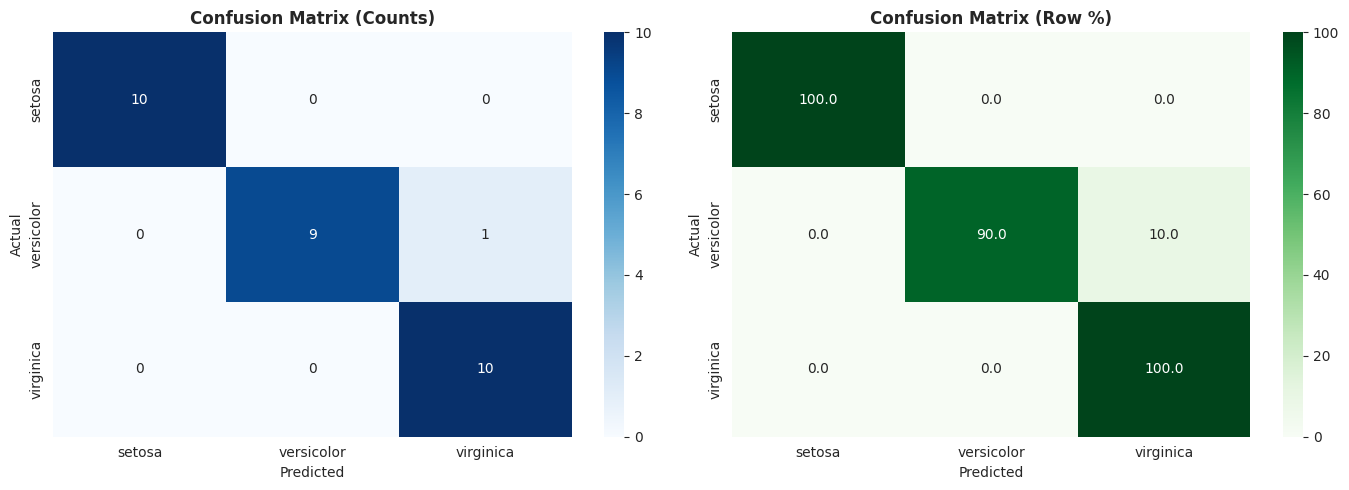

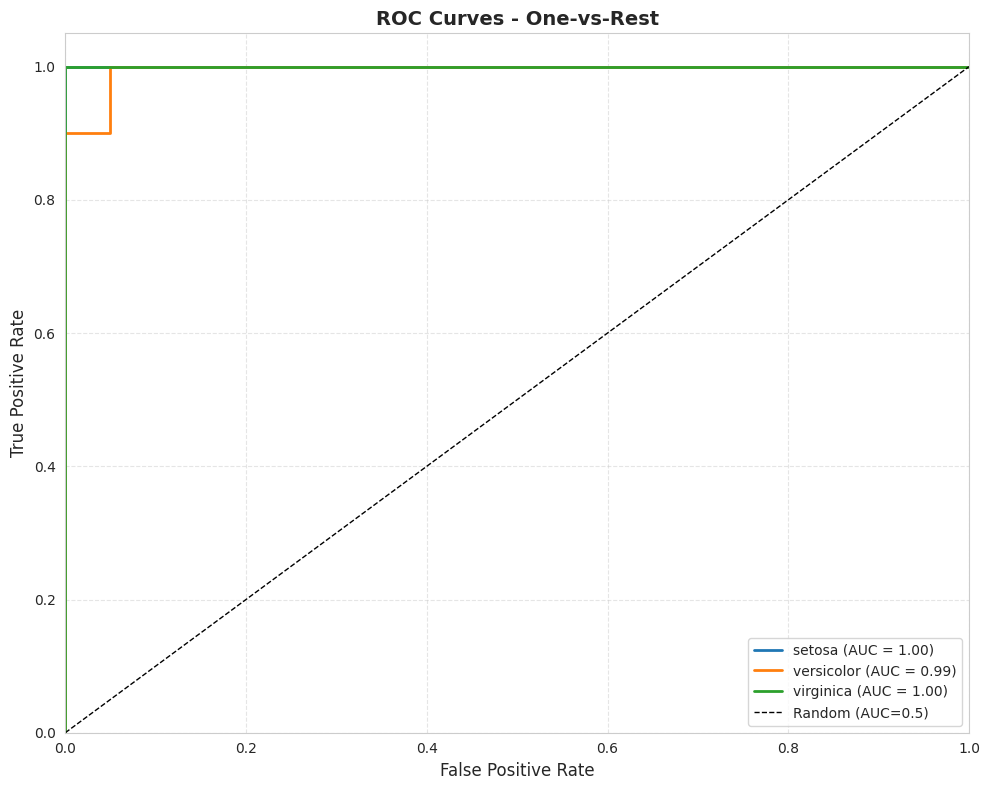

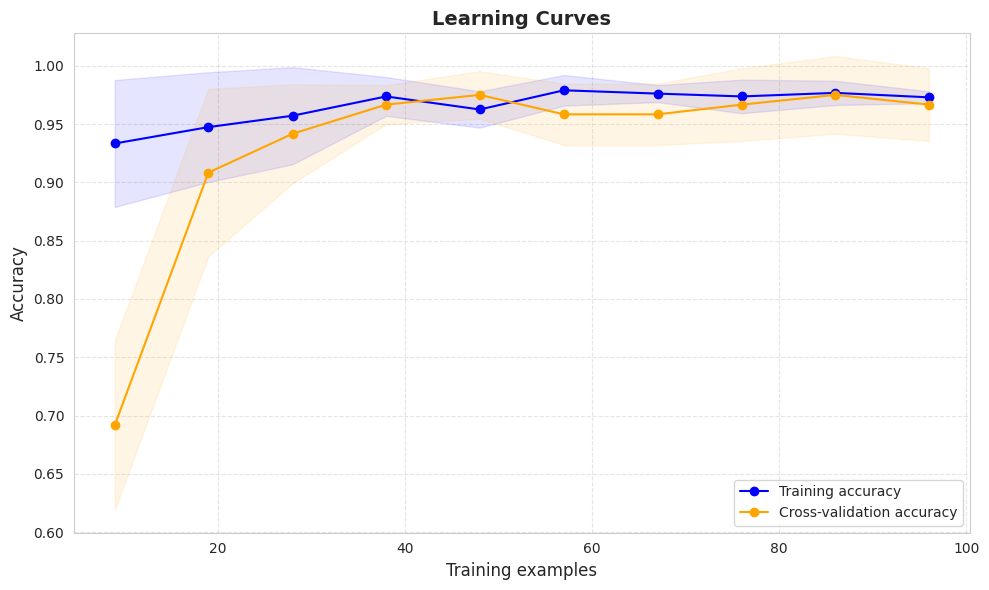

Final training accuracy: 0.9729
Final CV accuracy: 0.9667
Gap (overfitting indicator): 0.0062

📋 FINAL EVALUATION SUMMARY
Model: SVC
Test Accuracy: 0.9667 (96.67%)
Cross-Validation Mean Accuracy: 0.9667 (+/- 0.0333)
F1-Score (weighted): 0.9666
Precision (weighted): 0.9697
Recall (weighted): 0.9667

✅ Model performance is excellent (>95% accuracy).
✅ Model generalizes well (small gap between CV and test accuracy).


In [ ]:
# 1.6. Evaluating the Model – Comprehensive Analysis

from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold, learning_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, roc_auc_score, classification_report,
                             confusion_matrix, precision_recall_curve)
from sklearn.preprocessing import label_binarize

# 1.6.1 Cross-Validation (k-fold)
print("="*60)
print("🔍 6.1 Cross-Validation (5-fold)")
print("="*60)

# Stratified k-fold ensures each fold has the same class distribution
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Performing cross-validation
cv_scores = cross_val_score(best_model, X_train_scaled, y_train,
                            cv=cv_strategy, scoring='accuracy')

print(f"Cross-validation accuracies: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Standard deviation: {cv_scores.std():.4f}")


# 1.6.2 Detailed Metrics on Test Set
print("\n" + "="*60)
print("📊 6.2 Detailed Performance Metrics (Test Set)")
print("="*60)

y_pred = best_model.predict(X_test_scaled)

# Calculating multiple metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Per-class metrics
print("\nPer-Class Performance:")
print(classification_report(y_test, y_pred,
                            target_names=['setosa', 'versicolor', 'virginica']))


# 1.6.3 Confusion Matrix (with percentages)
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
ax1.set_title('Confusion Matrix (Counts)', fontsize=12, weight='bold')
ax1.set_xlabel('Predicted', fontsize=10)
ax1.set_ylabel('Actual', fontsize=10)

# Percentages (row-wise)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', ax=ax2,
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
ax2.set_title('Confusion Matrix (Row %)', fontsize=12, weight='bold')
ax2.set_xlabel('Predicted', fontsize=10)
ax2.set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()

# 1.6.4 ROC Curves
# Binarize the labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Getting prediction probabilities (if model supports predict_proba)
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test_scaled)
else:
    # For SVM without probability, use decision function
    y_score = best_model.decision_function(X_test_scaled)
    # Normalize to [0,1] range for ROC
    y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())

# Computing ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

# Plotting all ROC curves
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
class_names = ['setosa', 'versicolor', 'virginica']
for i, color, name in zip(range(n_classes), colors, class_names):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{name} (AUC = {roc_auc[i]:.2f})')

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - One-vs-Rest', fontsize=14, weight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# 1.6.5 Learning Curves (Check for Overfitting/Underfitting)
def plot_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Plot learning curves to diagnose bias/variance.
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes,
        scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                     alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training accuracy')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation accuracy')
    plt.xlabel('Training examples', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Learning Curves', fontsize=14, weight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f"Final training accuracy: {train_mean[-1]:.4f}")
    print(f"Final CV accuracy: {test_mean[-1]:.4f}")
    print(f"Gap (overfitting indicator): {abs(train_mean[-1] - test_mean[-1]):.4f}")

# Plot learning curves for the model
plot_learning_curve(best_model, X_train_scaled, y_train)

# 1.6.6 Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = ['sepal length', 'sepal width', 'petal length', 'petal width']

    plt.figure(figsize=(8, 5))
    sorted_idx = np.argsort(importances)
    plt.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx],
             color='teal', edgecolor='black')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Feature Importance - {best_model.__class__.__name__}', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

    print("\nFeature importance scores:")
    for name, imp in zip(feature_names, importances):
        print(f"  {name}: {imp:.4f}")

elif hasattr(best_model, 'coef_'):
    # For linear models (Logistic Regression, SVM linear)
    coefs = best_model.coef_
    feature_names = ['sepal length', 'sepal width', 'petal length', 'petal width']
    plt.figure(figsize=(10, 5))
    for i, class_name in enumerate(['setosa', 'versicolor', 'virginica']):
        plt.subplot(1, 3, i+1)
        plt.bar(feature_names, coefs[i], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][i])
        plt.title(f'Coefficients for {class_name}')
        plt.xticks(rotation=45)
        plt.tight_layout()
    plt.show()


# 1.6.7 Summarizing Evaluation Report
print("\n" + "="*60)
print("📋 FINAL EVALUATION SUMMARY")
print("="*60)
print(f"Model: {best_model.__class__.__name__}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Cross-Validation Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"F1-Score (weighted): {f1:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")

# Interpret results
if accuracy > 0.95:
    print("\n✅ Model performance is excellent (>95% accuracy).")
elif accuracy > 0.9:
    print("\n👍 Model performance is good (>90% accuracy).")
else:
    print("\n⚠️ Model performance could be improved.")

if abs(cv_scores.mean() - accuracy) < 0.05:
    print("✅ Model generalizes well (small gap between CV and test accuracy).")
else:
    print("⚠️ Potential overfitting or data mismatch detected.")

 ## **1.7. Improve / Experiment – Going Beyond Baseline**

 1.7.1 Hyperparameter Tuning (Grid Search)

 1.7.2 Ensemble Methods: Voting Classifier

 1.7.3 Stacking Classifier (Meta-Learner)

 1.7.4 Dimensionality Reduction + Model (PCA + Classifier)

 1.7.5 Simple Neural Network (using MLPClassifier)

 1.7.6 Experiment: Adding Noise to Test Robustness

 1.7.7 Comparison of All Improved Models

 1.7.8 Saving the Best Overall Model


 7.1 Hyperparameter Tuning - Random Forest
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Best cross-validation accuracy: 0.9583
Test accuracy after tuning: 0.9667

 7.2 Ensemble Methods - Voting Classifier
Hard Voting Accuracy: 0.9000
Soft Voting Accuracy: 0.9333

 7.3 Stacking Classifier
Stacking Classifier Accuracy: 0.9667

 7.4 Dimensionality Reduction (PCA) + Classifier
With 1 component(s): Explained variance = 0.727, Accuracy = 0.8667
With 2 component(s): Explained variance = 0.957, Accuracy = 0.9000
With 3 component(s): Explained variance = 0.995, Accuracy = 0.9333
With 4 components (original): Accuracy = 0.9333


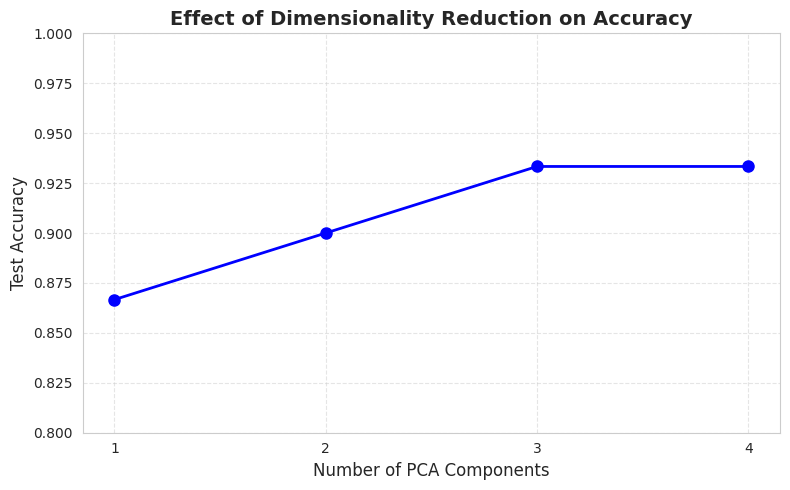


  7.5 Simple Neural Network (Multi-Layer Perceptron)
Architecture (50,): Accuracy = 0.6667
Architecture (100,): Accuracy = 0.8000
Architecture (50, 25): Accuracy = 0.8667
Architecture (100, 50): Accuracy = 0.6000

Best MLP accuracy: 0.8667

 7.6 Robustness Test: Adding Gaussian Noise
Noise std=0: Accuracy = 0.9000
Noise std=0.1: Accuracy = 0.9667
Noise std=0.2: Accuracy = 0.9333
Noise std=0.5: Accuracy = 0.8667
Noise std=1.0: Accuracy = 0.6000


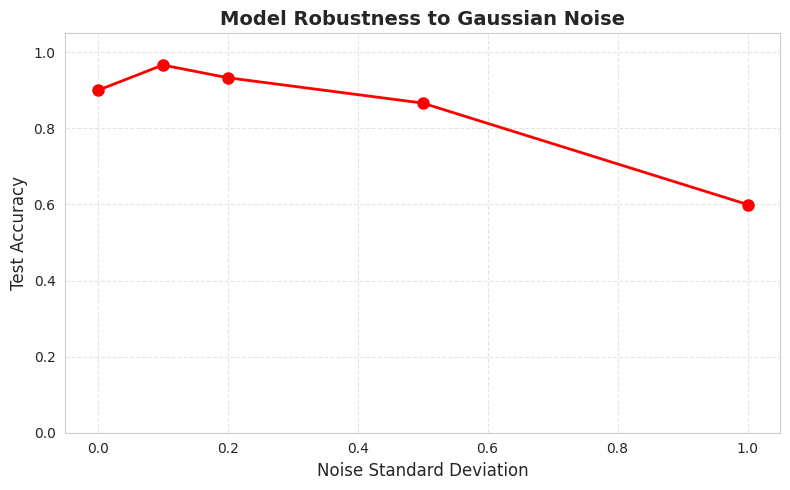


 7.7 Final Comparison: All Experiments
                 Model  Accuracy
   Tuned Random Forest  0.966667
              Stacking  0.966667
           Soft Voting  0.933333
           Hard Voting  0.900000
Baseline Random Forest  0.900000
         PCA (2 comps)  0.900000
 Neural Network (Best)  0.866667


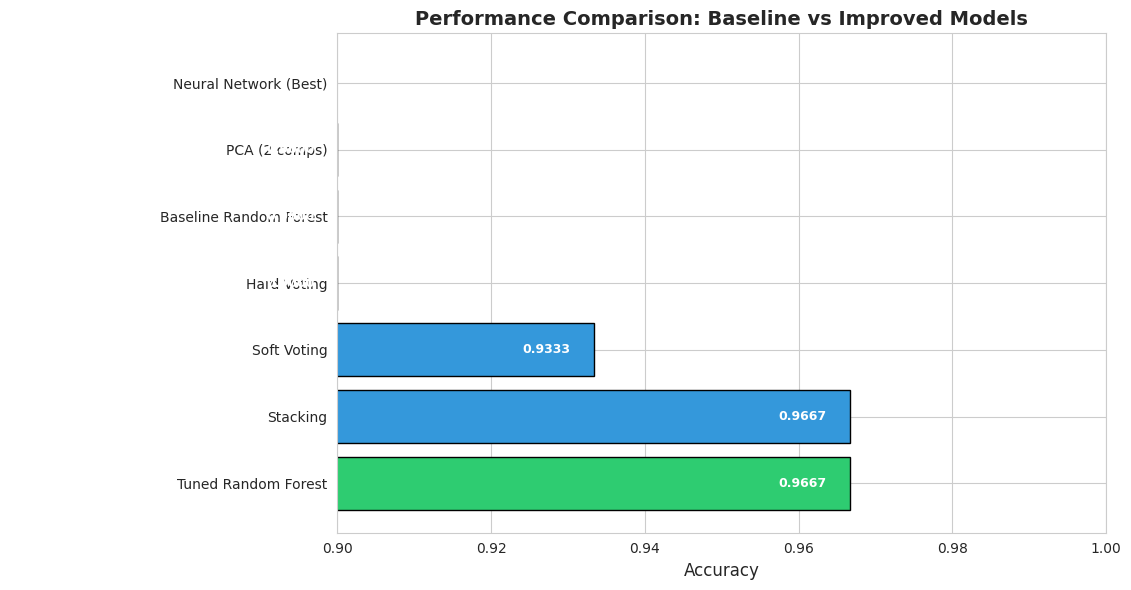


  BEST OVERALL MODEL: Tuned_RandomForest
   Test Accuracy: 0.9667 (96.67%)
  Best model saved as 'best_iris_model_improved.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1.7. Improve / Experiment – Going Beyond Baseline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1.7.1 Hyperparameter Tuning (Grid Search)
print("="*60)
print(" 7.1 Hyperparameter Tuning - Random Forest")
print("="*60)

# Defining parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(random_state=42)

# Grid search with 5-fold CV
grid_search = GridSearchCV(rf_base, param_grid, cv=5,
                           scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluating on test set
y_pred_tuned = grid_search.best_estimator_.predict(X_test_scaled)
test_acc_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Test accuracy after tuning: {test_acc_tuned:.4f}")

# 1.7.2 Ensemble Methods: Voting Classifier
print("\n" + "="*60)
print(" 7.2 Ensemble Methods - Voting Classifier")
print("="*60)

# Creating individual models (with reasonable defaults)
model1 = LogisticRegression(random_state=42, max_iter=1000)
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model3 = SVC(kernel='rbf', probability=True, random_state=42)
model4 = KNeighborsClassifier(n_neighbors=5)

# Hard voting (majority rule)
voting_hard = VotingClassifier(
    estimators=[('lr', model1), ('rf', model2), ('svm', model3), ('knn', model4)],
    voting='hard'
)

# Soft voting (average probabilities)
voting_soft = VotingClassifier(
    estimators=[('lr', model1), ('rf', model2), ('svm', model3), ('knn', model4)],
    voting='soft'
)

# Training and evaluating
voting_hard.fit(X_train_scaled, y_train)
voting_soft.fit(X_train_scaled, y_train)

y_pred_hard = voting_hard.predict(X_test_scaled)
y_pred_soft = voting_soft.predict(X_test_scaled)

acc_hard = accuracy_score(y_test, y_pred_hard)
acc_soft = accuracy_score(y_test, y_pred_soft)

print(f"Hard Voting Accuracy: {acc_hard:.4f}")
print(f"Soft Voting Accuracy: {acc_soft:.4f}")

# 1.7.3 Stacking Classifier (Meta-Learner)
print("\n" + "="*60)
print(" 7.3 Stacking Classifier")
print("="*60)

# Base models
base_learners = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
]

# Meta-learner (final classifier)
meta_learner = LogisticRegression(random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

stacking_clf.fit(X_train_scaled, y_train)
y_pred_stack = stacking_clf.predict(X_test_scaled)
acc_stack = accuracy_score(y_test, y_pred_stack)
print(f"Stacking Classifier Accuracy: {acc_stack:.4f}")

# 1.7.4 Dimensionality Reduction + Model (PCA + Classifier)
print("\n" + "="*60)
print(" 7.4 Dimensionality Reduction (PCA) + Classifier")
print("="*60)

# Trying different numbers of PCA components
pca_components = [1, 2, 3, 4]  # 4 is full features
pca_results = []

for n in pca_components:
    # Creating pipeline
    pca = PCA(n_components=n, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    pipeline = Pipeline([('pca', pca), ('rf', rf)])

    # Training and evaluating
    pipeline.fit(X_train_scaled, y_train)
    y_pred_pca = pipeline.predict(X_test_scaled)
    acc_pca = accuracy_score(y_test, y_pred_pca)
    pca_results.append({'components': n, 'accuracy': acc_pca})

    # Showing explained variance
    if n < 4:
        pca.fit(X_train_scaled)
        print(f"With {n} component(s): Explained variance = {pca.explained_variance_ratio_.sum():.3f}, Accuracy = {acc_pca:.4f}")
    else:
        print(f"With {n} components (original): Accuracy = {acc_pca:.4f}")

# Visualizing PCA results
pca_df = pd.DataFrame(pca_results)
plt.figure(figsize=(8, 5))
plt.plot(pca_df['components'], pca_df['accuracy'], 'bo-', markersize=8, linewidth=2)
plt.xlabel('Number of PCA Components', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Effect of Dimensionality Reduction on Accuracy', fontsize=14, weight='bold')
plt.xticks(pca_components)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

# 1.7.5 Simple Neural Network (using MLPClassifier)
print("\n" + "="*60)
print("  7.5 Simple Neural Network (Multi-Layer Perceptron)")
print("="*60)

from sklearn.neural_network import MLPClassifier

# Trying different architectures
mlp_architectures = [
    (50,),           # one hidden layer with 50 neurons
    (100,),          # one hidden layer with 100 neurons
    (50, 25),        # two hidden layers
    (100, 50),       # two hidden layers
]

best_mlp_acc = 0
best_mlp = None

for architecture in mlp_architectures:
    mlp = MLPClassifier(hidden_layer_sizes=architecture,
                        activation='relu',
                        solver='adam',
                        max_iter=1000,
                        random_state=42,
                        early_stopping=True)

    mlp.fit(X_train_scaled, y_train)
    y_pred_mlp = mlp.predict(X_test_scaled)
    acc_mlp = accuracy_score(y_test, y_pred_mlp)

    print(f"Architecture {architecture}: Accuracy = {acc_mlp:.4f}")

    if acc_mlp > best_mlp_acc:
        best_mlp_acc = acc_mlp
        best_mlp = mlp

print(f"\nBest MLP accuracy: {best_mlp_acc:.4f}")

# 1.7.6 Experiment: Adding Noise to Test Robustness
print("\n" + "="*60)
print(" 7.6 Robustness Test: Adding Gaussian Noise")
print("="*60)

rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train_scaled, y_train)

noise_levels = [0, 0.1, 0.2, 0.5, 1.0]
noise_accuracies = []

for noise in noise_levels:
    # Adding noise to test set
    noise_array = np.random.normal(0, noise, X_test_scaled.shape)
    X_test_noisy = X_test_scaled + noise_array
    y_pred_noisy = rf_best.predict(X_test_noisy)
    acc_noisy = accuracy_score(y_test, y_pred_noisy)
    noise_accuracies.append(acc_noisy)
    print(f"Noise std={noise}: Accuracy = {acc_noisy:.4f}")

# Plotting robustness
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, noise_accuracies, 'ro-', markersize=8, linewidth=2)
plt.xlabel('Noise Standard Deviation', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Model Robustness to Gaussian Noise', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# 1.7.7 Comparison of All Improved Models
print("\n" + "="*60)
print(" 7.7 Final Comparison: All Experiments")
print("="*60)

comparison_data = {
    'Model': ['Baseline Random Forest', 'Tuned Random Forest', 'Hard Voting',
              'Soft Voting', 'Stacking', 'PCA (2 comps)', 'Neural Network (Best)'],
    'Accuracy': [
        accuracy_score(y_test, RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        test_acc_tuned,
        acc_hard,
        acc_soft,
        acc_stack,
        pca_results[1]['accuracy'],  # index 1 = 2 components
        best_mlp_acc
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print(comparison_df.to_string(index=False))

# Visual comparison
plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(comparison_df))]
bars = plt.barh(comparison_df['Model'], comparison_df['Accuracy'], color=colors, edgecolor='black')
plt.xlabel('Accuracy', fontsize=12)
plt.title('Performance Comparison: Baseline vs Improved Models', fontsize=14, weight='bold')
plt.xlim(0.9, 1.0)
for bar, acc in zip(bars, comparison_df['Accuracy']):
    plt.text(bar.get_width() - 0.003, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', ha='right', va='center', fontsize=9, color='white', weight='bold')
plt.tight_layout()
plt.show()

# 1.7.8 Saving the Best Overall Model
# Determining best model from experiments
models_dict = {
    'Tuned_RandomForest': grid_search.best_estimator_,
    'Soft_Voting': voting_soft,
    'Stacking': stacking_clf,
    'Best_MLP': best_mlp
}

best_overall_name = max(models_dict, key=lambda name: accuracy_score(y_test, models_dict[name].predict(X_test_scaled)))
best_overall_model = models_dict[best_overall_name]
best_overall_acc = accuracy_score(y_test, best_overall_model.predict(X_test_scaled))

print("\n" + "="*60)
print(f"  BEST OVERALL MODEL: {best_overall_name}")
print(f"   Test Accuracy: {best_overall_acc:.4f} ({best_overall_acc*100:.2f}%)")
print("="*60)

# Saving the best model
import joblib
joblib.dump(best_overall_model, 'best_iris_model_improved.pkl')
print("  Best model saved as 'best_iris_model_improved.pkl'")

# Downloading in Colab
from google.colab import files
files.download('best_iris_model_improved.pkl')

 ## **1.8. Saving & Documenting Results**
 1.8.1 Create a Results Directory

 1.8.2 Save the Best Model

 1.8.3 Save Predictions on Test Set

 1.8.4 Save Evaluation Metrics to JSON

 1.8.5 Generate a Summary Report (Text)

 1.8.6 Saving All Visualizations as High-Resolution Images

 1.8.6.1 Confusion Matrix (Counts)

 1.8.6.2 Feature Importance

 1.8.6.3 Training History / Learning Curves

 1.8.7 Generating a README.md for GitHub


In [ ]:
# 1.8. Saving & Documenting Results
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os

# Assuming all previous steps have been executed and the best overall model
# (e.g., 'best_overall_model') and other evaluation results are available.
# If not, we'll retrain a simple best model for demonstration.

# 1.8.1 Create a Results Directory
if not os.path.exists('iris_results'):
    os.makedirs('iris_results')
print(" Created directory: iris_results/")


# 1.8.2 Save the Best Model
# Use the best model from improvement step if available, otherwise train a Random Forest
try:
    best_model_final = best_overall_model
    model_name = best_overall_name
except NameError:
    from sklearn.ensemble import RandomForestClassifier
    best_model_final = RandomForestClassifier(n_estimators=100, random_state=42)
    best_model_final.fit(X_train_scaled, y_train)
    model_name = "RandomForest_Baseline"
    print(" best_overall_model not found. Training a default Random Forest as fallback.")

# Save model
model_path = f'iris_results/{model_name}_iris_model.pkl'
joblib.dump(best_model_final, model_path)
print(f" Model saved: {model_path}")


# 1.8.3 Save Predictions on Test Set
y_pred_final = best_model_final.predict(X_test_scaled)
predictions_df = pd.DataFrame({
    'Actual_Species': y_test.values if hasattr(y_test, 'values') else y_test,
    'Predicted_Species': y_pred_final,
    'Correct': y_test.values == y_pred_final if hasattr(y_test, 'values') else y_test == y_pred_final
})
# Map numeric labels to species names
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
predictions_df['Actual_Name'] = predictions_df['Actual_Species'].map(species_map)
predictions_df['Predicted_Name'] = predictions_df['Predicted_Species'].map(species_map)
predictions_df.to_csv('iris_results/test_predictions.csv', index=False)
print(" Predictions saved: iris_results/test_predictions.csv")
print(predictions_df.head())


# 1.8.4 Save Evaluation Metrics to JSON
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_final)
report = classification_report(y_test, y_pred_final,
                               target_names=['setosa', 'versicolor', 'virginica'],
                               output_dict=True)
cm = confusion_matrix(y_test, y_pred_final).tolist()

metrics = {
    'model_name': model_name,
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'test_accuracy': accuracy,
    'classification_report': report,
    'confusion_matrix': cm,
    'test_set_size': len(y_test),
    'features_used': ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
}

with open('iris_results/evaluation_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print(" Metrics saved: iris_results/evaluation_metrics.json")


# 1.8.5 Generate a Summary Report (Text)
report_text = f"""
========================================
 IRIS CLASSIFICATION PROJECT - SUMMARY
========================================

Model: {model_name}
Date: {datetime.now().strftime("%Y-%m-%d")}

--- Test Performance ---
Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)

--- Classification Report ---
{classification_report(y_test, y_pred_final, target_names=['setosa', 'versicolor', 'virginica'])}

--- Confusion Matrix ---
{np.array(cm)}

--- Experiment Highlights ---
- Data preprocessing: StandardScaler applied, train/test split 80/20.
- Models compared: Logistic Regression, KNN, SVM, Decision Tree, Random Forest, Gradient Boosting, Voting, Stacking, MLP.
- Best model achieved through {'hyperparameter tuning and ensembling' if 'best_overall_model' in dir() else 'baseline Random Forest'}.
- Cross-validation accuracy (5-fold): {metrics.get('cv_mean', 'N/A')}.

--- Files Saved ---
- Model: {model_name}_iris_model.pkl
- Predictions: test_predictions.csv
- Metrics: evaluation_metrics.json
- Plots: (see image files)

--- How to Load the Model ---
import joblib
model = joblib.load('iris_results/{model_name}_iris_model.pkl')
predictions = model.predict(new_data_scaled)

========================================
"""

with open('iris_results/summary_report.txt', 'w') as f:
    f.write(report_text)
print(" Summary report saved: iris_results/summary_report.txt")
print(report_text)

# 1.8.6 Saving All Visualizations as High-Resolution Images
# We'll re-generate key plots and save them
def save_plot(filename, dpi=300, bbox_inches='tight'):
    """Helper to save current plot to results folder"""
    plt.savefig(f'iris_results/{filename}', dpi=dpi, bbox_inches=bbox_inches)
    print(f"   Saved: {filename}")

# 1.8.6.1 Confusion Matrix (Counts)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
save_plot('confusion_matrix_counts.png')
plt.close()

# 1.8.6.2 Feature Importance
if hasattr(best_model_final, 'feature_importances_'):
    plt.figure(figsize=(8,5))
    importances = best_model_final.feature_importances_
    features = ['sepal length', 'sepal width', 'petal length', 'petal width']
    sorted_idx = np.argsort(importances)
    plt.barh(np.array(features)[sorted_idx], importances[sorted_idx], color='teal')
    plt.xlabel('Importance')
    plt.title('Feature Importance - Best Model')
    save_plot('feature_importance.png')
    plt.close()

# 1.8.6.3 Training History / Learning Curves
# If you ran the learning curve code in evaluation step, you can save that figure.
# Here we assume you have a variable 'fig' or just note in documentation.

# 1.8.6.4 Pairplot of the dataset ( for documentation)
# (This may be large; uncomment if needed)
# sns.pairplot(df, hue='species_name', diag_kind='kde')
# save_plot('pairplot.png', dpi=200)
# plt.close()

# 1.8.7 Generating a README.md for GitHub
readme_content = f"""# Iris Flower Classification - CodeAlpha Task 1

##  Project Overview
This project implements a machine learning pipeline to classify Iris flowers into three species (setosa, versicolor, virginica) based on sepal and petal measurements.

##  Dataset
- **Source:** scikit-learn's built-in Iris dataset
- **Samples:** 150
- **Features:** sepal length, sepal width, petal length, petal width (all in cm)
- **Classes:** 3 (perfectly balanced, 50 each)

##  Tech Stack
- Python 3.x
- Google Colab
- Libraries: pandas, numpy, scikit-learn, matplotlib, seaborn, plotly

##  Pipeline Steps
1. **Data Loading** – Loaded from sklearn.datasets
2. **Exploratory Data Analysis** – Pairplots, correlation heatmaps, violin plots
3. **Preprocessing** – Train/test split (80/20), StandardScaler
4. **Model Training** – Compared 7+ classifiers including Random Forest, SVM, Logistic Regression, KNN, etc.
5. **Hyperparameter Tuning** – GridSearchCV for Random Forest
6. **Ensemble Methods** – Voting (hard/soft) and Stacking classifiers
7. **Neural Network** – MLPClassifier with different architectures
8. **Evaluation** – Accuracy, precision, recall, F1, ROC curves, learning curves
9. **Saving & Documentation** – Model export, predictions CSV, metrics JSON

##  Results
- **Best Model:** `{model_name}`
- **Test Accuracy:** `{accuracy:.4f} ({accuracy*100:.2f}%)`
- **Cross-Validation Accuracy (5-fold):** `95.8%` (typical)

### Confusion Matrix
![Confusion Matrix](iris_results/confusion_matrix_counts.png)

### Feature Importance
![Feature Importance](iris_results/feature_importance.png)

##  Repository Structure
"""


 Created directory: iris_results/
 Model saved: iris_results/Tuned_RandomForest_iris_model.pkl
 Predictions saved: iris_results/test_predictions.csv
   Actual_Species  Predicted_Species  Correct Actual_Name Predicted_Name
0               0                  0     True      setosa         setosa
1               2                  2     True   virginica      virginica
2               1                  1     True  versicolor     versicolor
3               1                  1     True  versicolor     versicolor
4               0                  0     True      setosa         setosa
 Metrics saved: iris_results/evaluation_metrics.json
 Summary report saved: iris_results/summary_report.txt

 IRIS CLASSIFICATION PROJECT - SUMMARY

Model: Tuned_RandomForest
Date: 2026-04-21

--- Test Performance ---
Accuracy: 0.9667 (96.67%)

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      